# Topographic position index (TPI) and terrain ruggedness index (TRI)

In [1]:
%load_ext autoreload
%autoreload 2
import os
from substrata import *

## Load in the pointcloud and annotations and scale/orient using predefined saved world transform

Loading project from YAML file: /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214.yaml
Loading pointcloud from /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214_dec50M.ply
Loading cameras from /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214.meta.json and /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214.cams.xml
Loading markers from /mnt/sdd/curacao_focal/cur_kal_40m_20200214/cur_kal_40m_20200214_markers.csv
Loading annotations from /home/pimbongaerts/Github/substrata/sandbox/mcav_sint/annotations/cur_kal_40m_ann.csv
Applying world_transform to loaded objects:
[[ 6.91815870e-03  8.81985760e-02 -5.38114188e-02  1.49175200e+01]
 [-8.74792065e-02 -2.36954925e-02 -5.00842348e-02  2.53525065e+00]
 [-5.49731391e-02  4.88062839e-02  7.29274924e-02 -3.88472494e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


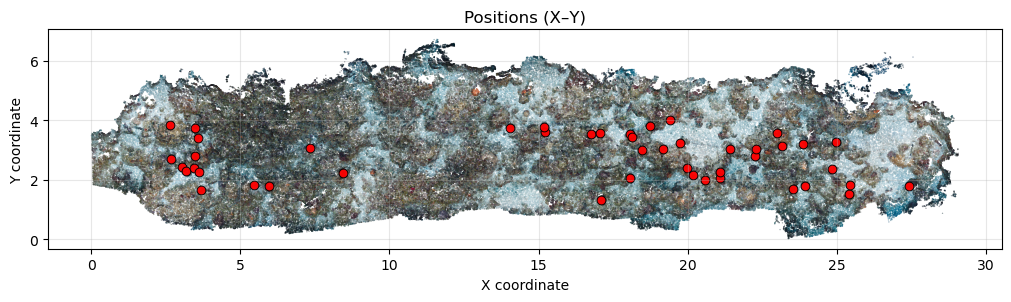

In [2]:
annotations_path = '/home/pimbongaerts/Github/substrata/sandbox/mcav_sint/annotations/'
output_path = '/home/pimbongaerts/Github/substrata/sandbox/mcav_sint/output/'

def load_plot_and_annotations(plot_path, annotations_path):
    plot = ProjectInitializer(path = plot_path)
    plot.reset_paths_to_local(plot_path)        # not required when running on server
    plot.annotations_filepath = annotations_path
    plot.initialize()
    return plot

# Example execution
plot = load_plot_and_annotations('/mnt/sdd/curacao_focal/cur_kal_40m_20200214/',
                                 os.path.join(annotations_path, 'cur_kal_40m_ann.csv'))
# Visualize annotations
plot.annotations.show(plot.pcd, color=True)

## Prepare for measurements and visualizations

In [3]:
# Load previously determined SA measurements
plot.annotations.load_measurements_from_csv("/home/pbongaerts/Github/substrata/sandbox/mcav_sint/annotations/all_SAs_clean.csv", id_column="sample_name")

# Correct camera path
plot.cams.set_filepath_replace("/home/deepcat/mounts/deepseal/coral3d/focal_plots/cur_kal/cur_kal_40m/",
                          "/mnt/sdd/curacao_focal/")

# Create buffered ortho to visualize annotation positions
ortho = OrthoMap(plot.pcd, pixel_width = 5000)

The following CSV IDs had no matching annotation (skipped): MCCPKA05G0469_purple, MCCPKA05G0471_green, MCCPKA05G0473_green, MCCPKA05G0474_green, MCCPKA05G0475_green, MCCPKA10G0476_blue, MCCPKA10G0477_blue, MCCPKA10G0480_blue, MCCPKA10G0481_blue, MCCPKA10G0482_blue, MCCPKA10G0487_blue, MCCPKA10G0491_green, MCCPKA10G0493_green, MCCPKA10G0494_blue, MCCPKA10G0495_green, MCCPKA10G0497_green, MCCPKA10G0498_green, MCCPKA10G0499_blue, MCCPKA10G0500_blue, MCCPKA10G0501_green, MCCPKA10G0502_green, MCCPKA10G0503_blue, MCCPKA10G0505_blue, MCCPKA20G0292_green, MCCPKA20G0293_blue, MCCPKA20G0311_blue, MCCPKA20G0312_blue, MCCPKA20G0315_blue, MCCPKA20G0318_green, MCCPKA20G0321_green, MCCPKA20G0329_blue, MCCPKA20G0330_blue, MCCPKA20G0334_blue, MCCPKA20G0386_blue, MCCPKA20G0388_green, MCCPKA20G0390_blue, MCCPKA20G0394_blue, MCCPKA20G0395_blue, MCCPKA20G0396_blue, MCCPKA20G0398_blue, MCCPKA20G0399_blue, MCCPKA20G0400_blue, MCCPKA20G0404_blue, MCCPKA20G0405_green, MCCPKA20G0406_blue, MCCPKA20G0507_blue, MC

## Calculate and visualize topographic position index (TPI) and terrain ruggedness index (TRI)

The topographic position index (TPI) is a metric of slope position, described in Weiss (2001), that corresponds to the difference of the elevation of a central pixel with the average of that of neighbouring pixels. (source: [xDEM](https://xdem.readthedocs.io/en/stable/terrain.html#topographic-position-index)). In this implementation, the "central point" is the annotation point with the elevation defined by the z-coordinate (or by the mean z of points within an "inner radius" around the central point), the neighboring points are sampled from an annulus around the inner circle (so that the focal object is excluded). In addition to the absolute value, a slope-correcting measure (TPI_plane) is also returned representing the signed perpendicular distance of the center point to the best-fit plane of the annulus points.

The terrain ruggedness index (TRI) is a metric of terrain ruggedness, based on cumulated differences in elevation between a central pixel and its surroundings. For bathymetry, the method of Wilson et al. (2007) is generally used, where the TRI is defined by the mean absolute difference with neighbouring pixels. (source: [xDEM](https://xdem.readthedocs.io/en/stable/terrain.html#terrain-ruggedness-index). In this implementation, it calculates the mean absolute z-difference between the "central point" and all annulus points.  In addition, a slope-correcting measure (TRI_plane) is also returned, based on the mean absolute perpendicular distance of annulus points from the best-fit plane.

Getting first image matches:   0%|          | 0/5 [00:00<?, ?it/s]

Subsampling pointcloud for each annotation:   0%|          | 0/5 [00:00<?, ?it/s]

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

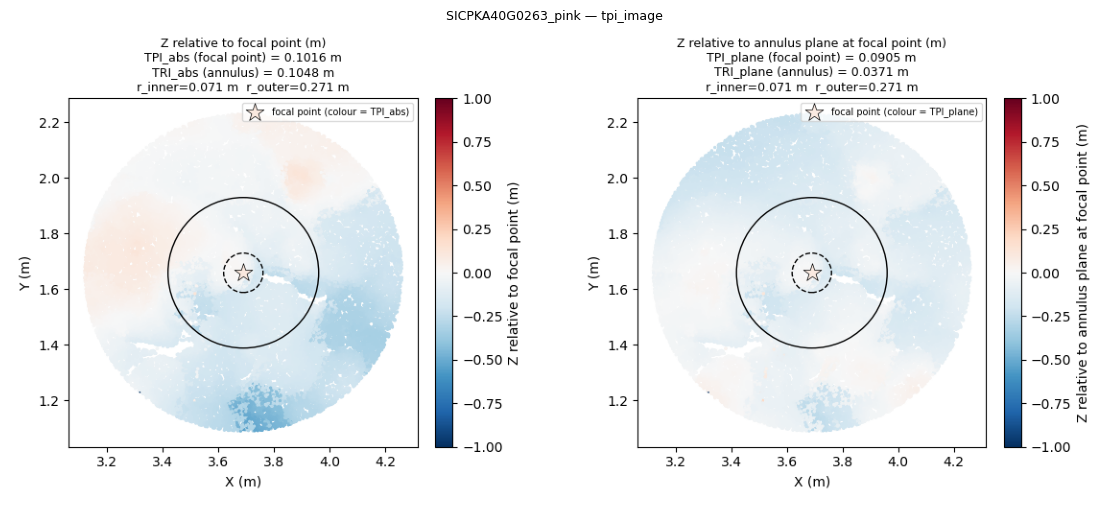

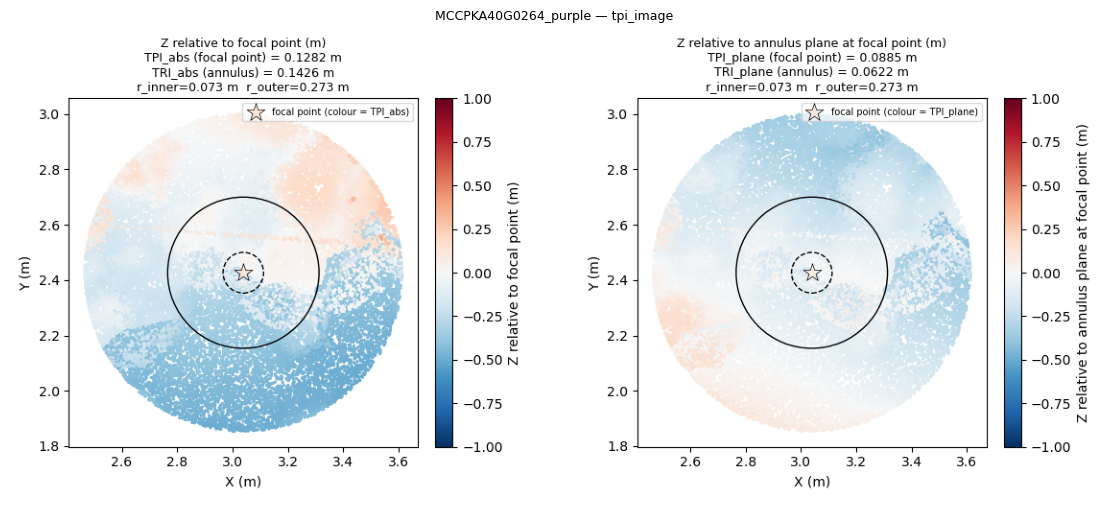

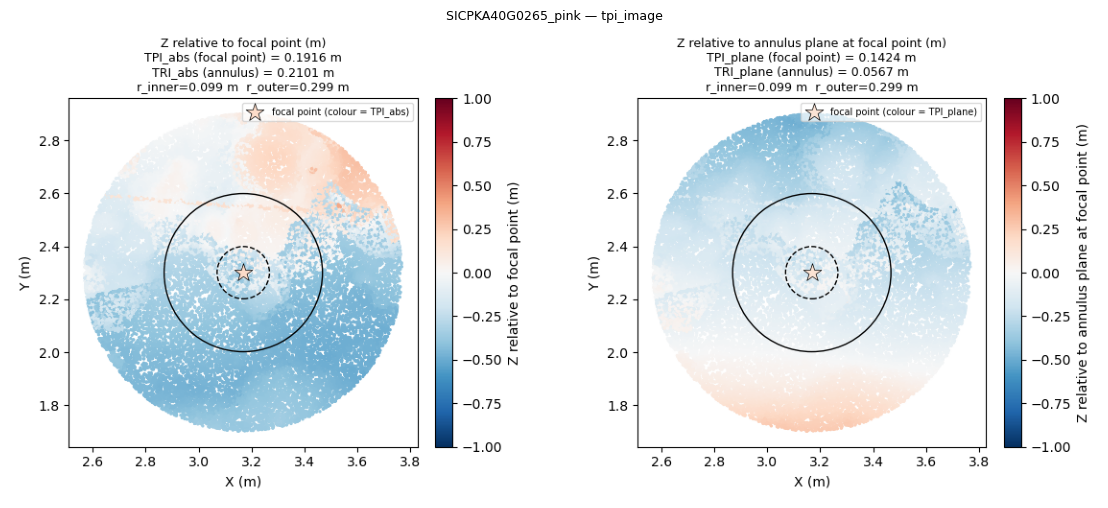

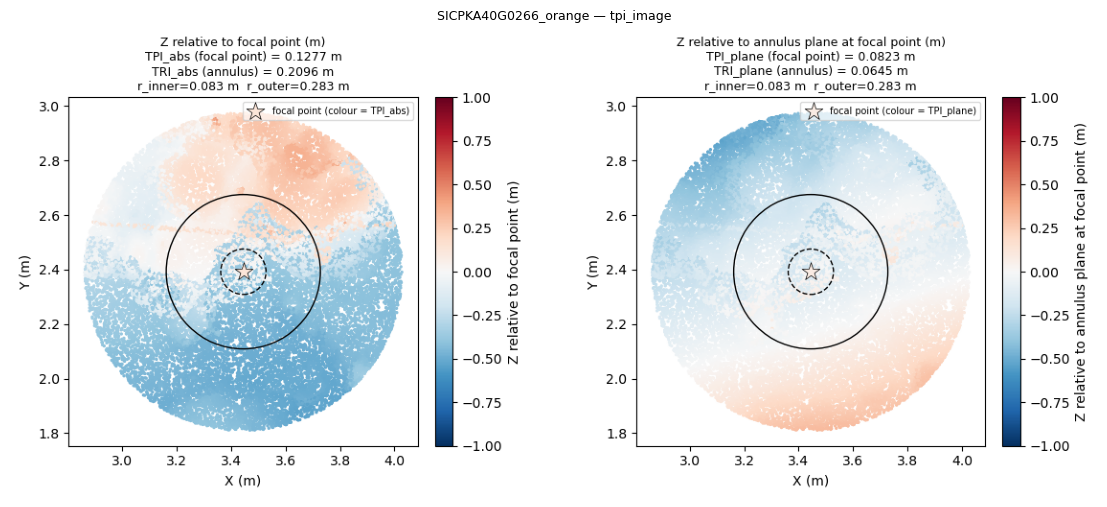

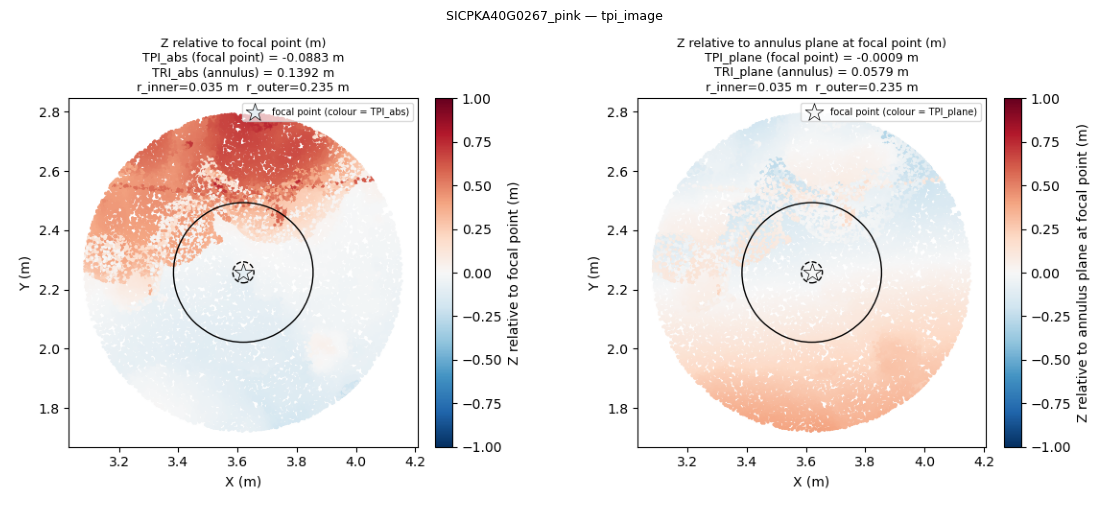

In [4]:
# Calculate TPI and TRI for the first 5 annotations
annotations = plot.annotations.subset(5)

annotations.get_first_image_matches(plot.cams)

# Sample point cloud around annotations with 0.5m cylinder radius buffer (= beyond the colony radius)
annotations.get_radius_from_2D_surface_area()
annotations.get_point_cloud_by_radius(plot.pcd, cylinder=True, radius_buffer=0.5)

# Calculate microhabitat measurements (using a custom radius for each colony and considering
# a 0.2m annulus neighborhood around the colony
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.2)

for ann in annotations:
    ann.show_measurement_images()


In [5]:
# Output measurement visualizations to PDF (with ortho and images/crops)
visualizations.save_measurement_visualizations_to_pdf(annotations, 
                                                      '/home/pimbongaerts/Github/substrata/docs/notebooks/tpi_report.pdf',
                                                      orthomap=ortho)

Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0709 m
Center: (6219, 3254), radius: 346 px
Mask area: 376081 pixels = 0.0158 m²


Rasterizing (447x447 px): 100%|███████████████████████████████████████████████████████| 101/101 [00:00<00:00, 13732.65it/s]


Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0734 m
Center: (5767, 3075), radius: 430 px
Mask area: 580833 pixels = 0.0169 m²


Rasterizing (447x447 px): 100%|████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 9647.57it/s]


Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0988 m
Center: (2917, 2855), radius: 515 px
Mask area: 833189 pixels = 0.0307 m²


Rasterizing (447x447 px): 100%|████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 9677.32it/s]


Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0833 m
Center: (3272, 3456), radius: 389 px
Mask area: 475337 pixels = 0.0218 m²


Rasterizing (447x447 px): 100%|████████████████████████████████████████████████████████| 101/101 [00:00<00:00, 9386.76it/s]


Annotations 'up_vector' and/or depth_offset not set
Created circular mask 1: radius 0.0355 m
Center: (4767, 2904), radius: 145 px
Mask area: 66045 pixels = 0.0039 m²


Rasterizing (447x447 px): 100%|███████████████████████████████████████████████████████| 101/101 [00:00<00:00, 10460.64it/s]


## Different parameter options

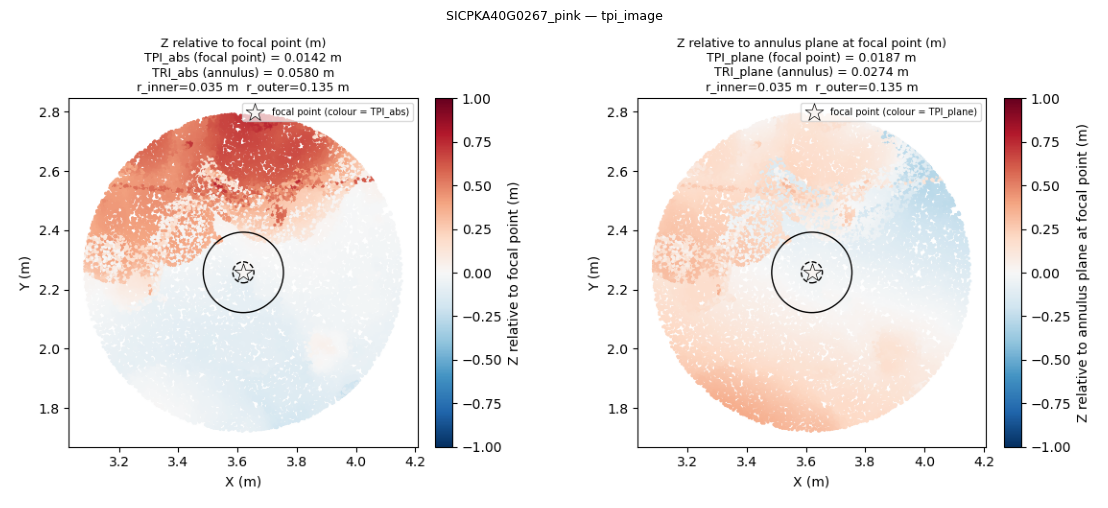

In [6]:
# Calculate TPI and TRI for the first 5 annotations
example_annotation = plot.annotations['SICPKA40G0267_pink']

example_annotation.get_first_image_match(plot.cams)

# Sample point cloud around annotations with 0.5m cylinder radius buffer (= beyond the colony radius)
example_annotation.get_radius_from_2D_surface_area()
example_annotation.get_point_cloud_by_radius(plot.pcd, cylinder=True, radius_buffer=0.5)

# Calculate microhabitat measurements (using a custom radius for each colony and considering
# a 0.1m annulus neighborhood around the colony)
example_annotation.measure(calc_tpi_and_tri, annulus_width=0.1)
example_annotation.show_measurement_images()


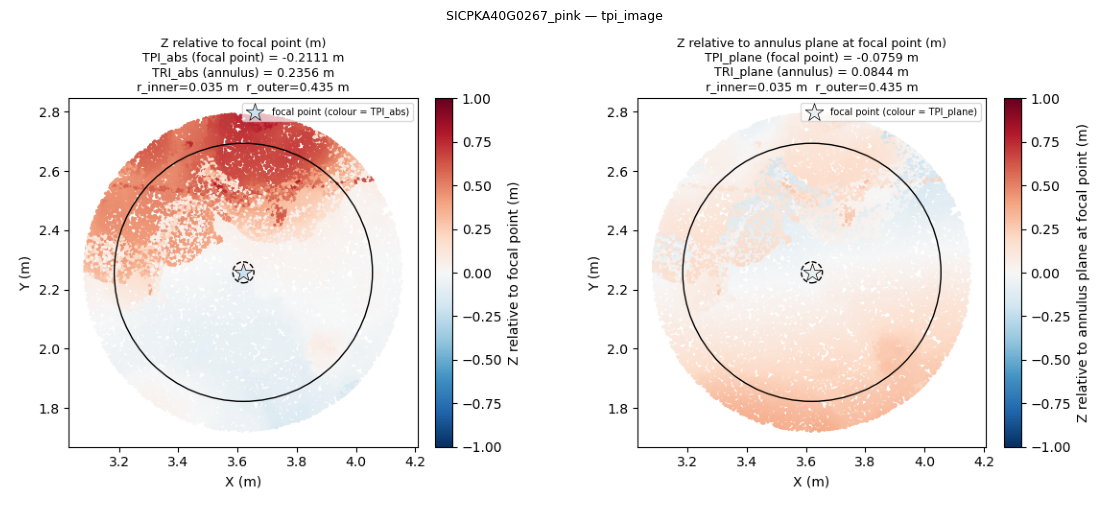

In [7]:
# Using a wider annulus and using the the mean z of the inner radius
# (rather than the z-coordinate of the annotation directly)
example_annotation.measure(calc_tpi_and_tri, annulus_width=0.4, center_z_from_inner = True)
example_annotation.show_measurement_images()

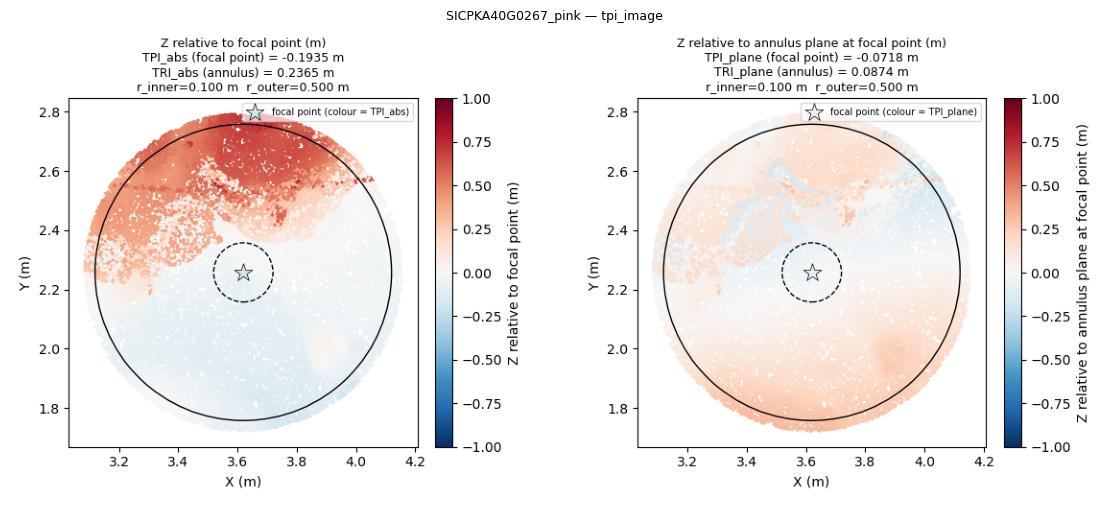

In [8]:
# The TPI and TRI can also be calculated with a fixed inner and outer radius
example_annotation.measure(calc_tpi_and_tri, radius_inner=0.1, radius_outer=0.5)
example_annotation.show_measurement_images()

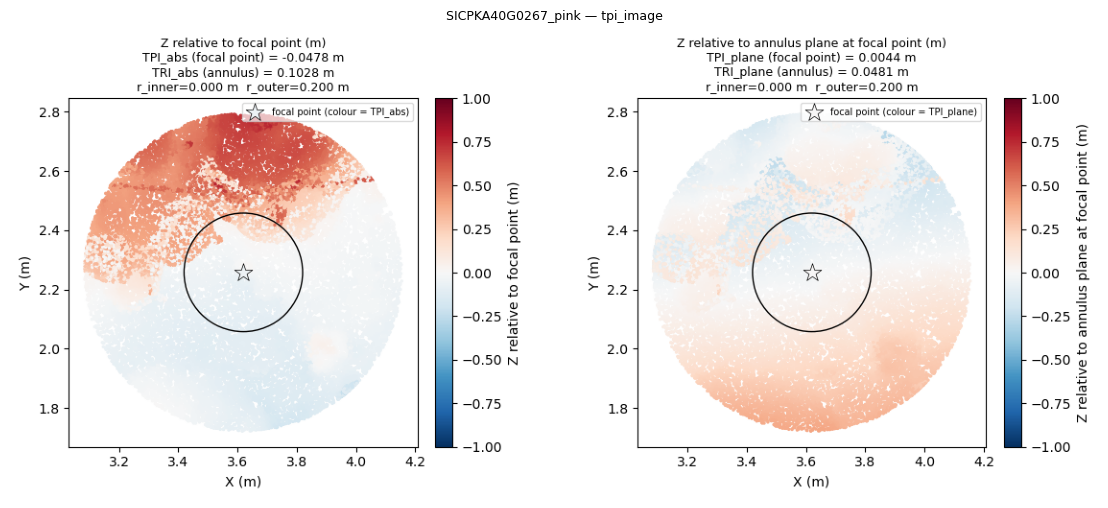

In [9]:
# Or the colony can be included in the measurement (no annulus)
example_annotation.measure(calc_tpi_and_tri, radius_inner=0, radius_outer=0.2)
example_annotation.show_measurement_images()

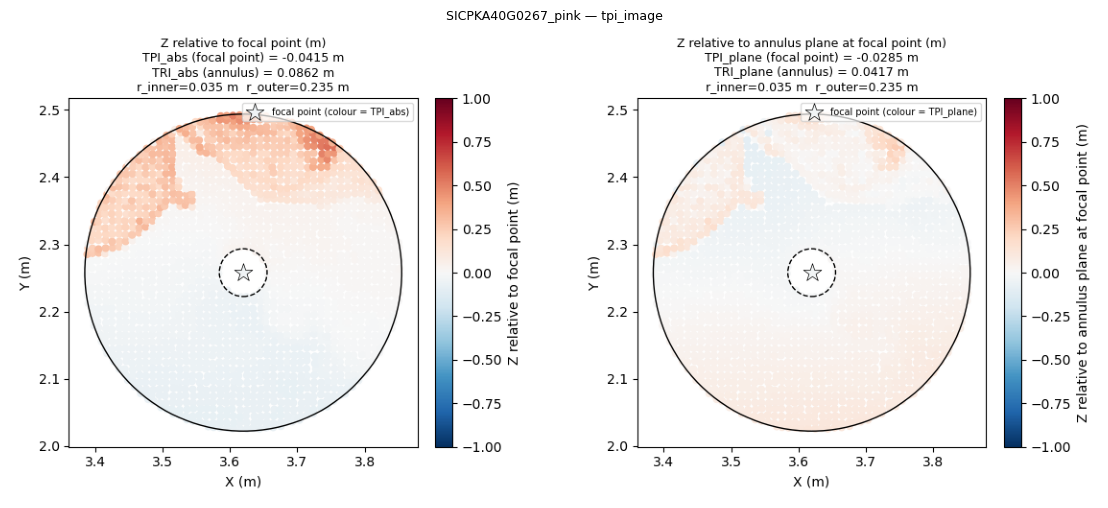

In [10]:
# It can also rasterize the XY space to avoid biases due to varying point densities
# (with the mean z value used for each raster cell - the rasterization is also used for calculating
# the mean z of the inner radius)
example_annotation.measure(calc_tpi_and_tri, annulus_width=0.2, center_z_from_inner = True,
                           raster_cell_size = 0.01)
example_annotation.show_measurement_images()

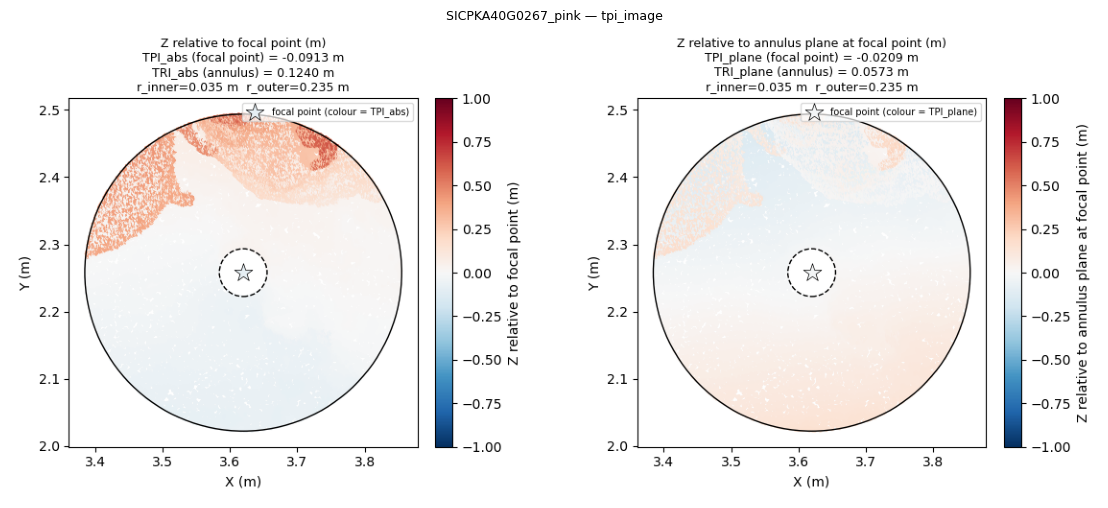

In [11]:
# Fine rasterization
example_annotation.measure(calc_tpi_and_tri, annulus_width=0.2, center_z_from_inner = True,
                           raster_cell_size = 0.001)
example_annotation.show_measurement_images()

## Comparison of different parameter options - different neighborhood size (=annulus width)

Subsampling pointcloud for each annotation:   0%|          | 0/46 [00:00<?, ?it/s]

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

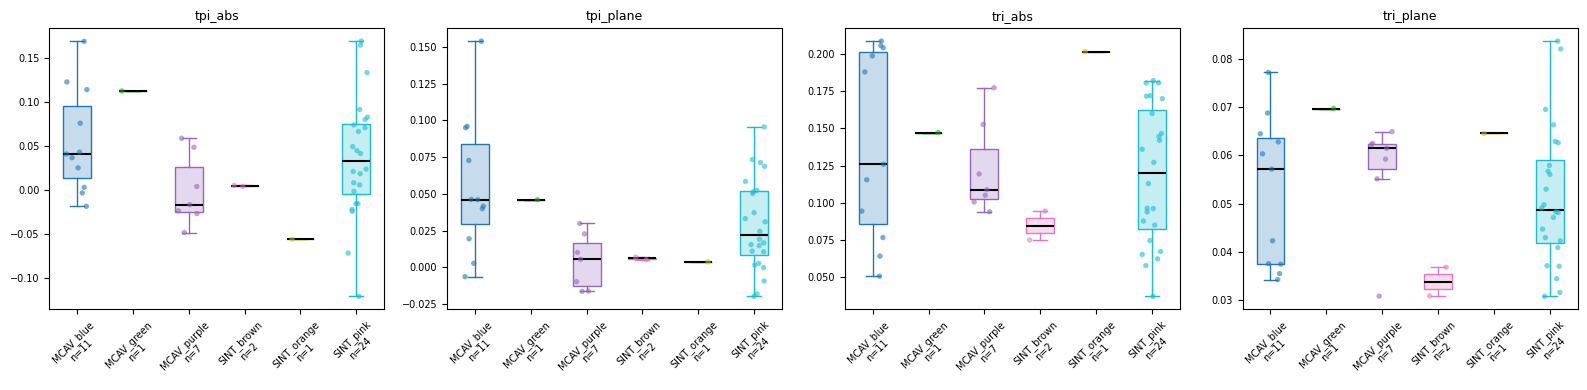

In [12]:
# Calculate across all annotations in plot
annotations = plot.annotations

# Sample point cloud around annotations with 0.7m cylinder radius
annotations.get_radius_from_2D_surface_area()
annotations.get_point_cloud_by_radius(plot.pcd, cylinder=True, radius_buffer=0.7)

# Calculate microhabitat measurements
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.2, center_z_from_inner=True)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])


Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

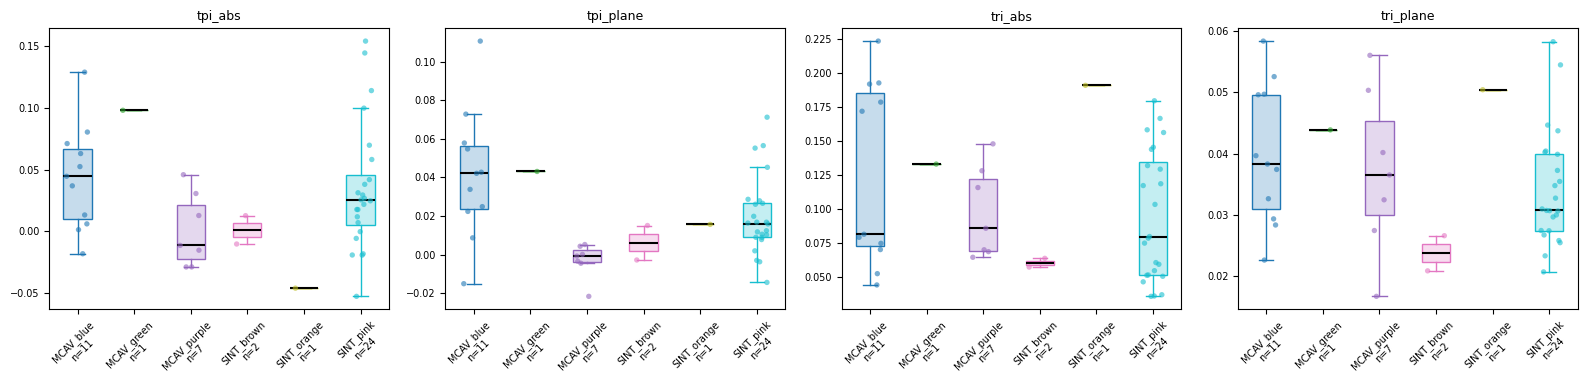

In [13]:
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.1, center_z_from_inner=True)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

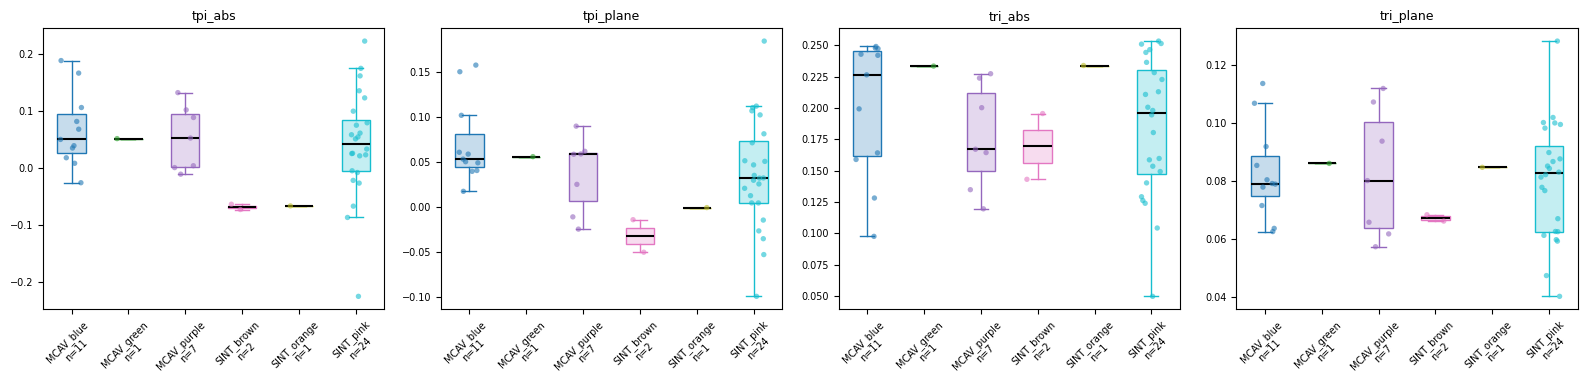

In [14]:
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.5, center_z_from_inner=True)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])

## Comparison of different parameter options - z or mean z from inner

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

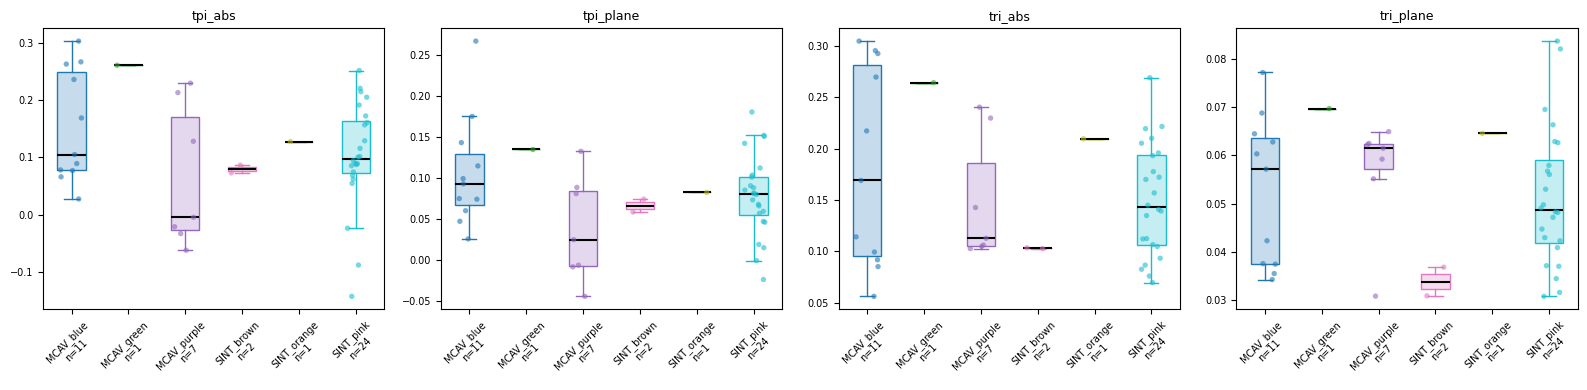

In [15]:
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.2, center_z_from_inner=False)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

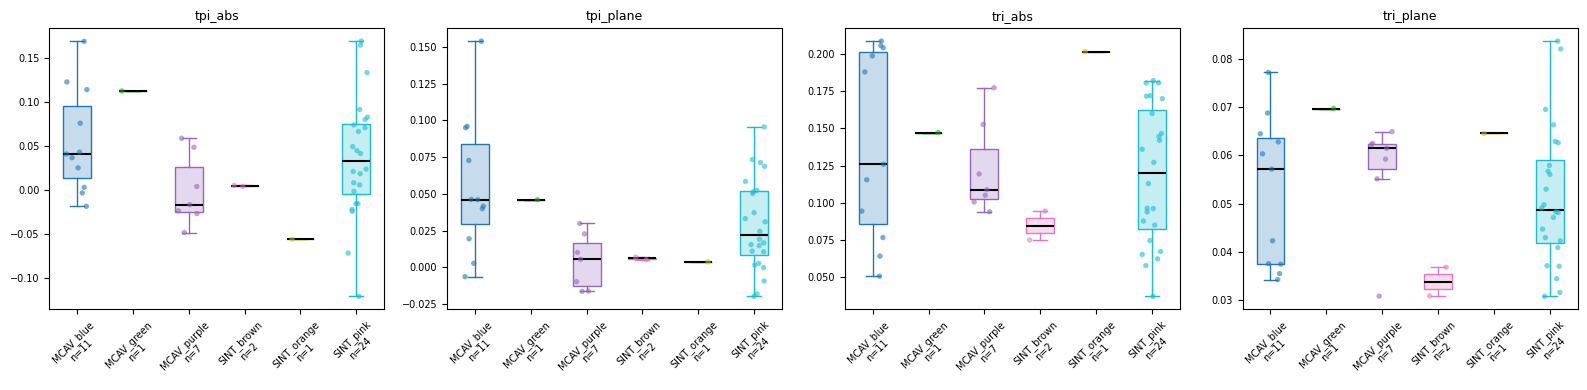

In [16]:
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.2, center_z_from_inner=True)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])

## Comparison of different parameter options - rasterization

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

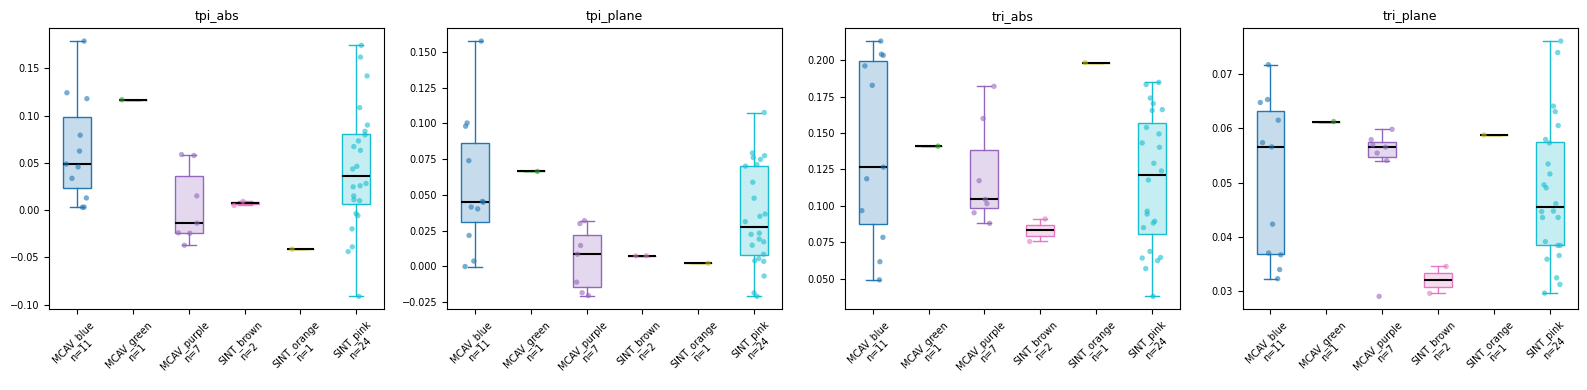

In [17]:
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.2, center_z_from_inner=True, raster_cell_size=0.001)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

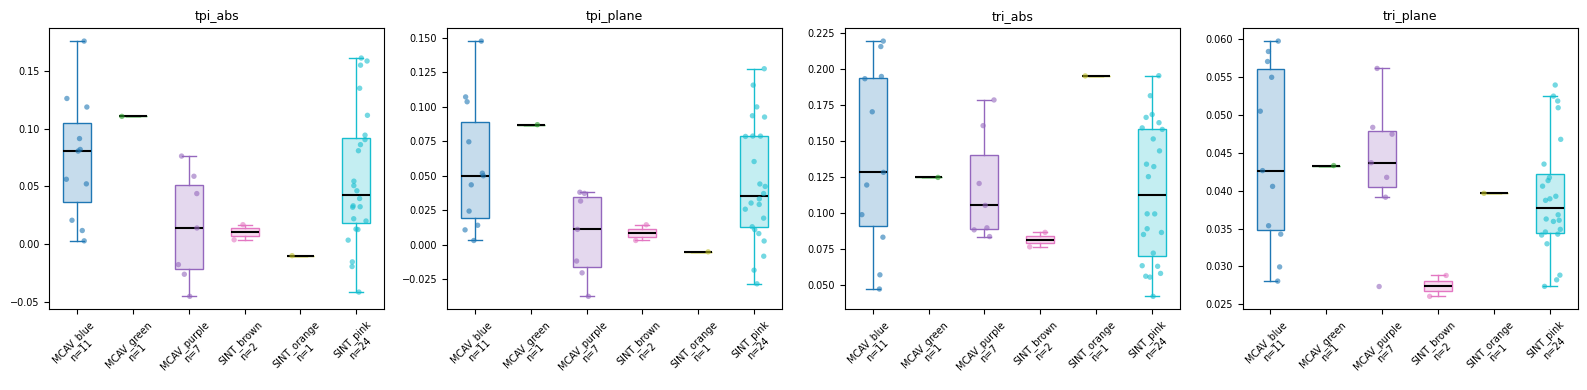

In [18]:
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.2, center_z_from_inner=True, raster_cell_size=0.01)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

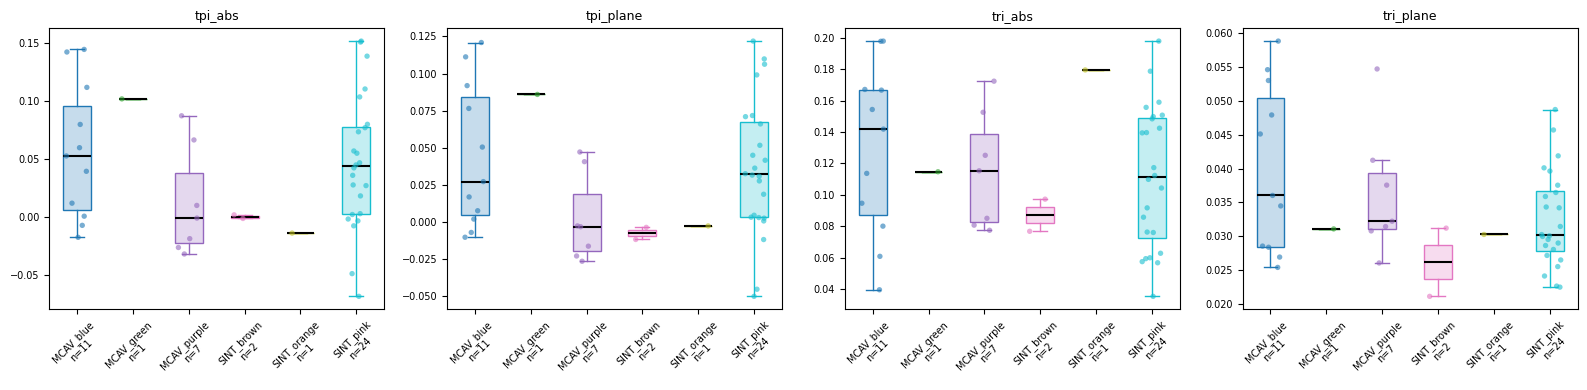

In [19]:
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.2, center_z_from_inner=True, raster_cell_size=0.1)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])

## Comparison of different parameter options - with or without coral colony

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

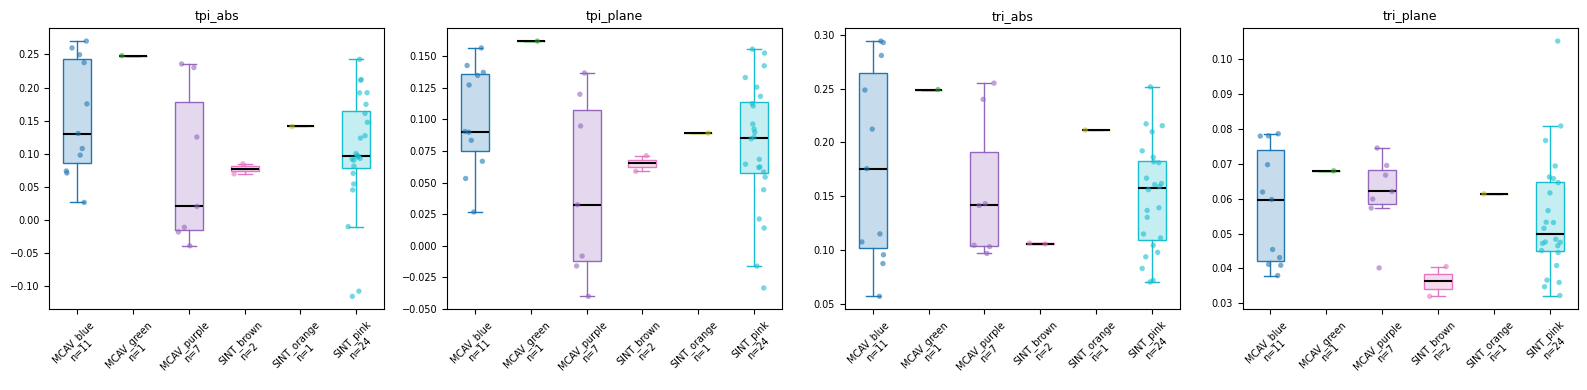

In [20]:
annotations.measure_all("calc_tpi_and_tri", radius_inner=0, radius_outer=0.3, raster_cell_size=0.001)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])

Conducting <function calc_tpi_and_tri at 0x77f95db8bd00> measurement for all annotations...:   0%|          | …

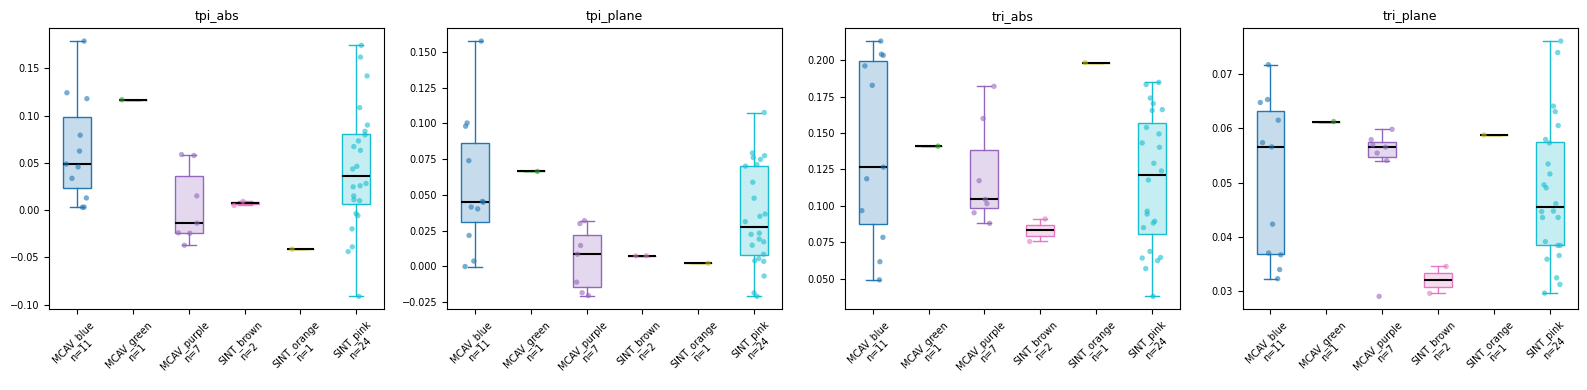

In [21]:
annotations.measure_all("calc_tpi_and_tri", annulus_width=0.2, center_z_from_inner=True, raster_cell_size=0.001)
fig = visualizations.plot_measurements(annotations, measurements=["tpi_abs", "tpi_plane", "tri_abs", "tri_plane"])

## Comparison with roughness parameter

In [23]:
# Using a 0.3m radius for Ra to be comparable to annulus_width=0.2 + avg colony size
annotations.get_point_cloud_by_radius(plot.pcd, cylinder=True, radius=0.3)
annotations.measure_all("calc_roughness")
fig = visualizations.plot_measurements(annotations, measurements=["Ra", "Rq", "tri_abs", "tri_plane"])

Subsampling pointcloud for each annotation:   0%|          | 0/46 [00:00<?, ?it/s]

Conducting <function calc_roughness at 0x77f95db8bc70> measurement for all annotations...:   0%|          | 0/…

  0%|          | 0/46 [00:00<?, ?it/s]

PicklingError: Could not pickle the task to send it to the workers.